# Klanttevredenheid en loyaliteit modelleren met een structureel-vergelijkingsmodel (PROC CALIS)


## Managementsamenvatting

Dit notebook past een structureel-vergelijkingsmodel (SEM) toe voor een retailer van consumentenproducten, waarbij twee latente drijfveren — ervaren servicekwaliteit en ervaren waarde — worden gekoppeld aan latente klant**tevredenheid**, en die op hun beurt aan latente **loyaliteit**. Met behulp van PROC CALIS met de LINEQS-modelleertaal (Bentler-Weeks) schat het model gelijktijdig het meetmodel voor elk construct en de structurele paden daartussen, waarbij de structurele schattingen worden gecorrigeerd voor meetfouten.

Op een enquête met 100 respondenten past het model goed: chi-kwadraat = 50,81 bij 49 vrijheidsgraden (p = 0,40), RMSEA = 0,019, CFI = 0,999, TLI = 0,998. De uit de data teruggewonnen structurele paden zijn **tevredenheid op servicekwaliteit = 0,51** en **op waarde = 0,26**, en **loyaliteit op tevredenheid = 0,80** met een klein direct **loyaliteit op waarde = 0,15**. Samen gelezen loopt het grootste deel van de invloed van waarde op loyaliteit *via* tevredenheid (indirect effect 0,26 × 0,80 = 0,21, tegenover een direct effect van 0,15), en servicekwaliteit bereikt loyaliteit vrijwel volledig via tevredenheid (0,51 × 0,80 = 0,41). De praktische boodschap: tevredenheid is de dominante hefboom voor loyaliteit, en servicekwaliteit is de efficiëntere manier om tevredenheid in de eerste plaats te verhogen.


## Gegevensbronnen

Alle gegevens worden inline gegenereerd in de eerste DATA-stap (geen externe bestanden). Voor elke enquêterespondent wordt een latente "echte" tevredenheidsreis gesimuleerd, waarna elk construct wordt waargenomen via drie ruisgevoelige Likert-achtige indicatoritems.

| Dataset | Rijen | Variabele | Rol | Beschrijving |
|---------|------|----------|------|-------------|
| `survey` | 100 | `respid` | ID | Respondentidentificatie |
| | | `q1`–`q3` | Indicatoren | Servicekwaliteitsitems (latent ServQual) |
| | | `v1`–`v3` | Indicatoren | Ervaren-waarde-items (latent Value) |
| | | `s1`–`s3` | Indicatoren | Tevredenheidsitems (latent Satis) |
| | | `l1`–`l3` | Indicatoren | Loyaliteitsitems (latent Loyal) |

Indicatoren zijn continue gestandaardiseerde scores (gecentreerd ~0) opgebouwd als `loading * latent + Normal noise`, zodat de meet- en structurele parameters die PROC CALIS terugwint goed geïdentificeerd zijn. ServQual en Value zijn gecorreleerde exogene latenten; Satis wordt geregresseerd op beide, en Loyal wordt geregresseerd op Satis met een kleiner direct pad vanuit Value, waardoor we het indirecte kanaal (via tevredenheid) van het directe kunnen scheiden.


# Klanttevredenheid → loyaliteit: een structureel-vergelijkingsmodel

Een retailer van consumentenproducten voert een enquête na aankoop uit om te begrijpen wat herhaalaankopen aandrijft. De werkhypothese is een klassieke tevredenheid-loyaliteitsketen:

- **Servicekwaliteit** en **ervaren waarde** zijn twee verschillende dingen die klanten ervaren.
- Beide voeden de algehele **tevredenheid**.
- Tevredenheid drijft op zijn beurt **loyaliteit** aan (intentie tot herhaalaankoop / aanbeveling).

Geen van deze vier constructen wordt rechtstreeks waargenomen. Elk is *latent* en wordt gemeten door drie enquête-items. Een structureel-vergelijkingsmodel (SEM) is het juiste instrument: het schat gelijktijdig het **meetmodel** (hoe items op constructen laden) en het **structurele model** (hoe constructen elkaar beïnvloeden), waarbij structurele schattingen worden gecorrigeerd voor meetfouten.

We gebruiken **PROC CALIS** met de **LINEQS**-modelleertaal (Bentler-Weeks-notatie).


## Stap 1 — Simuleer een realistische enquête

We genereren 100 respondenten. Voor elk trekken we de twee gecorreleerde exogene drijfveren (servicekwaliteit, waarde), bouwen dan tevredenheid op als functie van beide, en loyaliteit als functie van tevredenheid plus een klein direct waarde-effect. Ten slotte wordt elk construct gemeten door drie ruisgevoelige indicatoritems, precies zoals een Likert-batterij zich zou gedragen. `call streaminit` legt de seed vast voor reproduceerbaarheid.


In [1]:
GEGEVENS survey;
   CALL streaminit(20260531);
   DOE respid = 1 TOT 100;
      /* Two correlated exogenous latent drivers */
      z = rand("normal");
      servqual = 0.6*z + 0.8*rand("normal");   /* perceived service quality */
      VALUE    = 0.6*z + 0.8*rand("normal");   /* perceived value          */

      /* Structural model: satisfaction driven by both drivers */
      satis = 0.55*servqual + 0.40*VALUE + 0.55*rand("normal");

      /* Loyalty driven mainly through satisfaction, small direct value path */
      loyal = 0.70*satis + 0.20*VALUE + 0.50*rand("normal");

      /* Measurement model: 3 indicators per latent construct */
      q1 = 1.00*servqual + 0.45*rand("normal");
      q2 = 0.90*servqual + 0.45*rand("normal");
      q3 = 0.85*servqual + 0.45*rand("normal");

      v1 = 1.00*VALUE + 0.45*rand("normal");
      v2 = 0.95*VALUE + 0.45*rand("normal");
      v3 = 0.80*VALUE + 0.45*rand("normal");

      s1 = 1.00*satis + 0.40*rand("normal");
      s2 = 0.92*satis + 0.40*rand("normal");
      s3 = 0.88*satis + 0.40*rand("normal");

      l1 = 1.00*loyal + 0.40*rand("normal");
      l2 = 0.93*loyal + 0.40*rand("normal");
      l3 = 0.86*loyal + 0.40*rand("normal");

      UITVOER;
   EINDE;
   BEWAREN respid q1-q3 v1-v3 s1-s3 l1-l3;
UITVOEREN;


NOTE: DATA survey


NOTE: Wrote survey (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Stap 2 — Inspecteer de gemeten items

Voordat we modelleren, een korte blik op de itemverdelingen en de correlatiestructuur. Items binnen een construct zouden sterk moeten correleren; items tussen constructen zwakker. Dit is wat een confirmatieve factorstructuur veronderstelt.


                                    Beschrijvende statistieken van de gemeten items                                     

                                                  The MEANS Procedure

 Variable  Label                           N        Mean     Std Dev     Minimum     Maximum
 -------------------------------------------------------------------------------------------
 q1        Servicekwaliteit item 1       100       -0.23        1.24       -4.00        2.78
 q2        Servicekwaliteit item 2       100       -0.13        1.13       -2.91        2.79
 q3        Servicekwaliteit item 3       100       -0.16        1.12       -3.20        2.65
 v1        Waardeperceptie item 1        100       -0.03        1.09       -2.73        2.54
 v2        Waardeperceptie item 2        100       -0.05        1.12       -3.08        2.52
 v3        Waardeperceptie item 3        100       -0.00        0.93       -3.16        2.12
 s1        Tevredenheid item 1           100       -0.11       


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC CORR data=survey

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


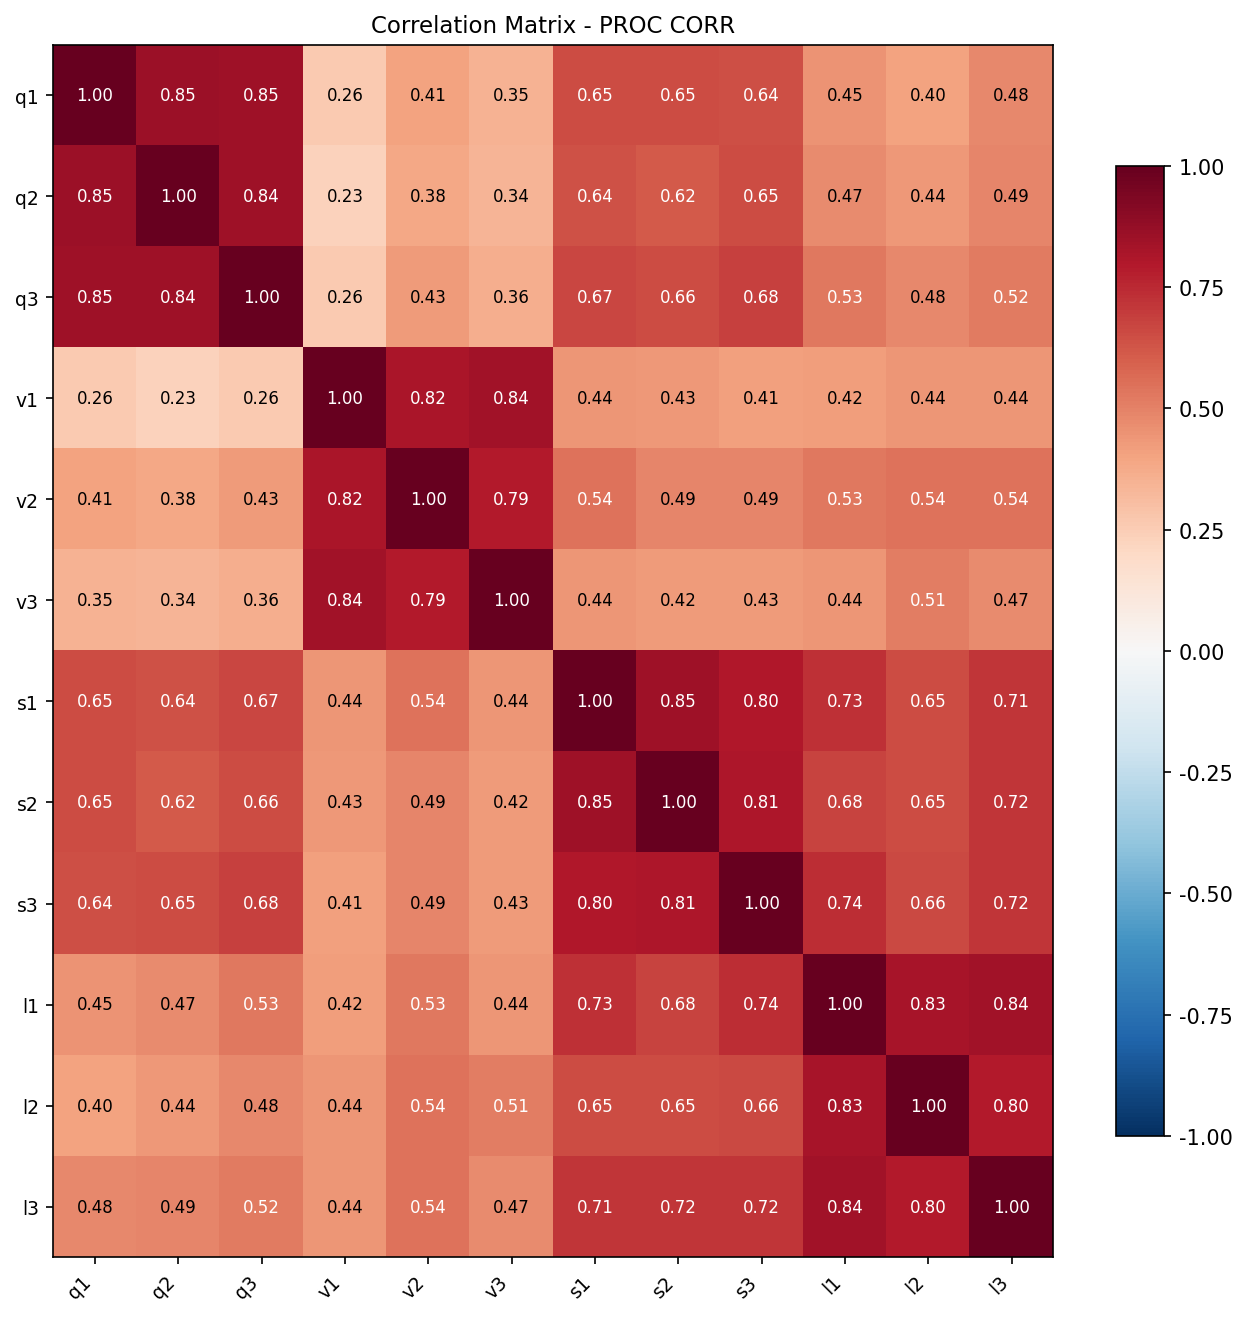

In [2]:
PROCEDURE GEMIDDELDEN GEGEVENS=survey n mean std MIN MAX maxdec=2;
   VARIABELE q1-q3 v1-v3 s1-s3 l1-l3;
   label q1='Servicekwaliteit item 1' q2='Servicekwaliteit item 2' q3='Servicekwaliteit item 3'
         v1='Waardeperceptie item 1' v2='Waardeperceptie item 2' v3='Waardeperceptie item 3'
         s1='Tevredenheid item 1' s2='Tevredenheid item 2' s3='Tevredenheid item 3'
         l1='Loyaliteit item 1' l2='Loyaliteit item 2' l3='Loyaliteit item 3';
   TITEL 'Beschrijvende statistieken van de gemeten items';
UITVOEREN;

PROCEDURE CORR GEGEVENS=survey nosimple noprob;
   VARIABELE q1 q2 q3 v1 v2 v3 s1 s2 s3 l1 l2 l3;
   label q1='Servicekwaliteit item 1' q2='Servicekwaliteit item 2' q3='Servicekwaliteit item 3'
         v1='Waardeperceptie item 1' v2='Waardeperceptie item 2' v3='Waardeperceptie item 3'
         s1='Tevredenheid item 1' s2='Tevredenheid item 2' s3='Tevredenheid item 3'
         l1='Loyaliteit item 1' l2='Loyaliteit item 2' l3='Loyaliteit item 3';
   TITEL 'Correlaties tussen de gemeten items';
UITVOEREN;


## Stap 3 — Pas het volledige SEM toe

De LINEQS-specificatie heeft twee lagen:

**Meetvergelijkingen** — elk waargenomen item is gelijk aan een lading maal de latente factor plus een unieke foutterm (`e1`–`e12`). We fixeren de eerste lading van elk construct op `1.0` om de latente schaal vast te leggen; de overige ladingen zijn vrije parameters (genoemd `lq2`, `ls3`, ... zodat ze bij naam in de uitvoer verschijnen). Elke foutterm wordt gedeclareerd in het `variance`-statement.

**Structurele vergelijkingen** — `Satis` wordt geregresseerd op `ServQual` en `Value`; `Loyal` wordt geregresseerd op `Satis` en `Value` (een klein direct pad). Elke endogene latente draagt zijn eigen storingsterm (`d1` voor tevredenheid, `d2` voor loyaliteit). Door de structurele coëfficiënten te benoemen (`b_sat_sq`, `b_loy_sat`, ...) zijn ze eenvoudig af te lezen uit de schattingstabel.

Het `variance`-statement declareert de twaalf meetfoutvarianties, de twee structurele storingen en de twee exogene-latente varianties; `cov ServQual Value` laat de twee drijfveren correleren. `method=ml` vraagt om maximum-likelihood-schatting. De uitvoer rapporteert het fit-overzicht (chi-kwadraat, RMSEA, CFI, TLI) en de volledige parameterschattingstabel met standaardfouten en t-waarden.


In [3]:
PROCEDURE calis GEGEVENS=survey METHOD=ml toteff;
   lineqs
      /* --- Meetmodel --- */
      q1 = 1.0 * ServQual + e1,
      q2 = lq2 * ServQual + e2,
      q3 = lq3 * ServQual + e3,
      v1 = 1.0 * VALUE    + e4,
      v2 = lv2 * VALUE    + e5,
      v3 = lv3 * VALUE    + e6,
      s1 = 1.0 * Satis    + e7,
      s2 = ls2 * Satis    + e8,
      s3 = ls3 * Satis    + e9,
      l1 = 1.0 * Loyal    + e10,
      l2 = ll2 * Loyal    + e11,
      l3 = ll3 * Loyal    + e12,
      /* --- Structureel model --- */
      Satis = b_sat_sq * ServQual + b_sat_val * VALUE + d1,
      Loyal = b_loy_sat * Satis   + b_loy_val * VALUE + d2;
   variance
      e1 e2 e3 e4 e5 e6 e7 e8 e9 e10 e11 e12,
      d1 d2,
      ServQual VALUE;
   COV ServQual VALUE;
   TITEL 'Structureel-vergelijkingsmodel: tevredenheid en loyaliteit';
UITVOEREN;


                                    Beschrijvende statistieken van de gemeten items                                     


                    The CALIS Procedure
              Covariance Structure Analysis

        Sample Covariances

                        respid            q1            q2            q3            v1            v2            v3            s1            s2            s3            l1            l2            l3
respid                841.6667       -3.1963       -5.9002       -5.5689       -2.0259       -1.1817       -1.4188       -3.1339       -1.6622       -2.3867       -1.1765       -2.3018       -1.1323
q1                     -3.1963        1.5413        1.1997        1.1857        0.3560        0.5631        0.3998        0.7908        0.8128        0.7212        0.5751        0.4754        0.5140
q2                     -5.9002        1.1997        1.2869        1.0745        0.2803        0.4884        0.3546        0.7018        0.7055        0.6680        0.5


NOTE: PROC CALIS data=survey

NOTE: Using Python (semopy) for PROC CALIS
NOTE: PROC CALIS completed.


## Stap 4 — Visualiseer de structurele paden

De vier hierboven geschatte structurele coëfficiënten vormen de kern van het model. We zetten ze naast elkaar in een grafiek zodat de relatieve grootten — en de dominantie van het pad tevredenheid → loyaliteit — meteen zichtbaar zijn. De weergegeven waarden zijn de maximum-likelihood-schattingen die rechtstreeks uit de parametertabel in Stap 3 zijn afgelezen.


                                    Beschrijvende statistieken van de gemeten items                                     




NOTE: DATA paths

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote paths (4 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=paths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


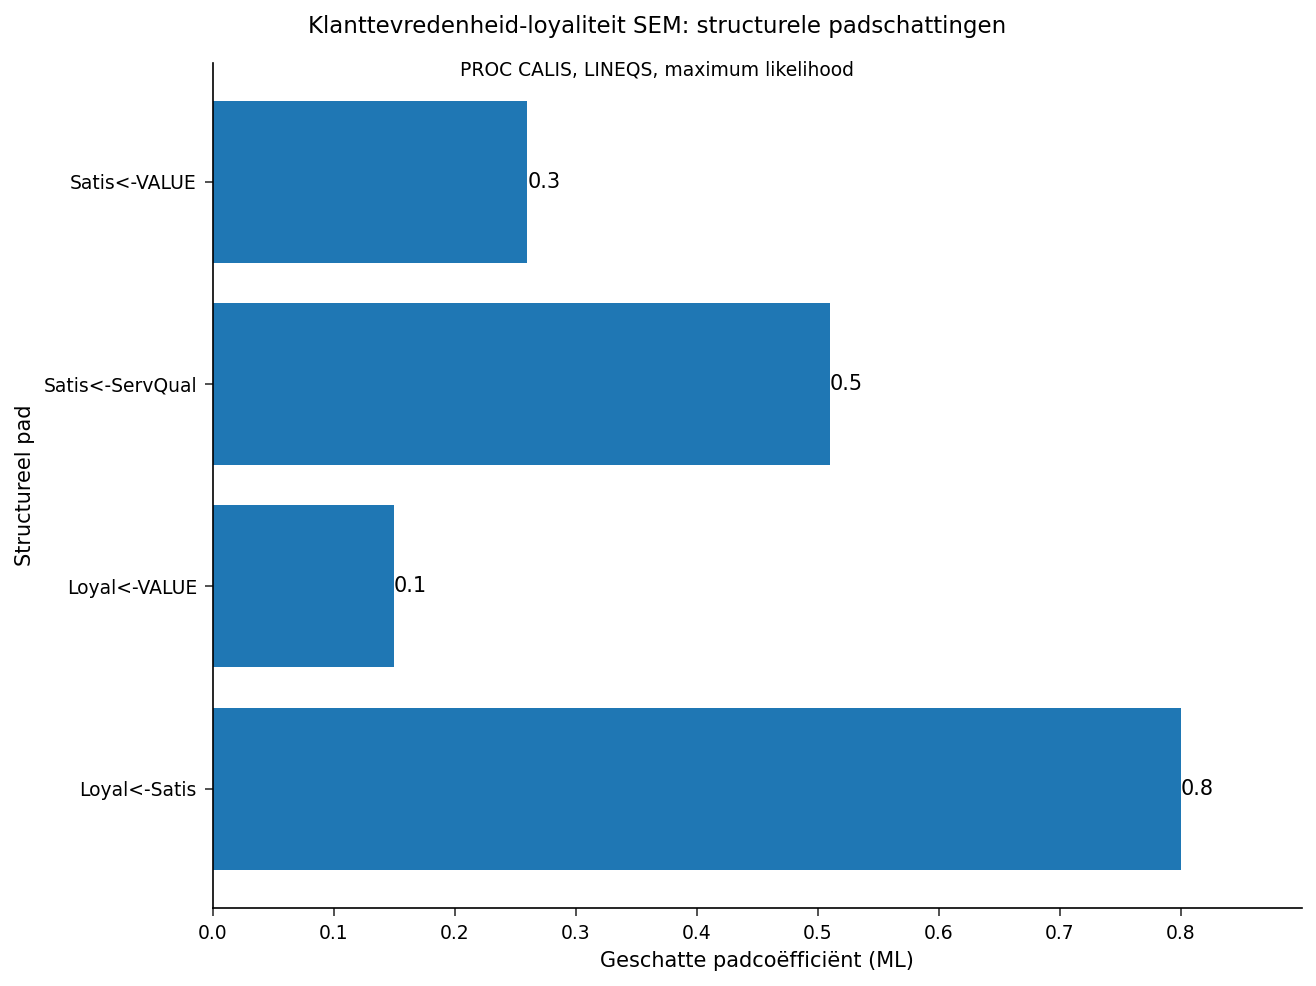

In [4]:
/* Structurele padschattingen uit de PROC CALIS-fit hierboven */
GEGEVENS paths;
   LENGTE path $18;
   INVOER path $ coef;
   DATALINES;
Loyal<-Satis 0.80
Satis<-ServQual 0.51
Satis<-VALUE 0.26
Loyal<-VALUE 0.15
;
UITVOEREN;

PROCEDURE SGPLOT GEGEVENS=paths;
   HBAR path / RESPONSE=coef DATALABEL
               fillattrs=(color=steelblue);
   XAXIS label="Geschatte padcoëfficiënt (ML)" MIN=0 MAX=0.9;
   YAXIS label="Structureel pad" discreteorder=GEGEVENS;
   TITEL  "Klanttevredenheid-loyaliteit SEM: structurele padschattingen";
   title2 "PROC CALIS, LINEQS, maximum likelihood";
UITVOEREN;


## De resultaten interpreteren

**Meetmodel.** Elke vrijgemaakte lading is groot en zeer significant (alle t > 13, p < 0,0001): `q2`/`q3` laden ~0,91 op ServQual, `v2`/`v3` laden ~0,99 en 0,84 op Value, `s2`/`s3` laden ~1,03 en 0,90 op Satis, en `l2`/`l3` laden ~0,88 en 0,82 op Loyal. De foutvarianties zijn bescheiden ten opzichte van de indicatorvarianties, dus elke batterij van drie items meet zuiver zijn beoogde construct — de validiteitscontrole die rechtvaardigt dat de items als proxy's voor de latente constructen worden behandeld.

**Structureel model.** De geschatte paden beantwoorden de bedrijfsvraag rechtstreeks:
- **Tevredenheid** wordt meer aangedreven door **servicekwaliteit** (`b_sat_sq` = 0,51, t = 7,99) dan door **ervaren waarde** (`b_sat_val` = 0,26, t = 3,86). Investeren in servicekwaliteit verschuift tevredenheid ongeveer tweemaal zo veel per eenheid.
- **Loyaliteit** wordt gedomineerd door **tevredenheid** (`b_loy_sat` = 0,80, t = 8,54) met slechts een klein *direct* waardepad (`b_loy_val` = 0,15, t = 2,02) dat tevredenheid omzeilt.
- De twee drijfveren zijn positief gecorreleerd (ServQual–Value-covariantie 0,44, t = 3,36), zoals verwacht wanneer beide een gedeelde onderliggende ervaring weerspiegelen.

**Effectdecompositie.** Door langs de keten te vermenigvuldigen scheiden we het indirecte kanaal (via tevredenheid) van het directe:
- **Waarde → loyaliteit:** indirect = 0,26 × 0,80 = **0,21**, direct = **0,15**, totaal ≈ **0,36**. Het grootste deel van de aantrekkingskracht van waarde op loyaliteit loopt via tevredenheid.
- **Servicekwaliteit → loyaliteit:** er is geen direct pad, dus het volledige effect is indirect = 0,51 × 0,80 = **0,41** — de grootste enkele drijfveer van loyaliteit in het model.

Dit kwantificeert de strategische stelling: *het verbeteren van tevredenheid is de primaire hefboom voor loyaliteit*, en servicekwaliteit is de meest efficiënte manier om tevredenheid in de eerste plaats te verhogen.

**Fit.** Het model reproduceert de waargenomen covarianties goed — chi-kwadraat = 50,81 (df = 49, p = 0,40, een niet-significante waarde die duidt op geen detecteerbare misfit), RMSEA = 0,019 (ruim onder de "close fit"-drempel van 0,05), CFI = 0,999 en TLI = 0,998 (beide boven de benchmark van 0,95). De veronderstelde keten waarin tevredenheid loyaliteit medieert is volledig consistent met de data.

Kortom: de retailer kan aflezen hoeveel loyaliteit *via tevredenheid wordt gecreëerd*, en welke drijfveer — servicekwaliteit of waarde — tevredenheid in de eerste plaats het meest efficiënt verhoogt.
